In [1]:
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt   
import seaborn as sns   
from scipy import stats
import warnings
import pickle   


from os import path

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report

from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
 

warnings.simplefilter('ignore')

pd.set_option('display.max_columns', None)


In [2]:
df_bin = pd.read_csv('bin_data.csv')


In [3]:
df_bin = df_bin.loc[:, ~df_bin.columns.str.contains('^Unnamed')]


In [4]:
le_1 = np.load("lebal_1_classes.npy",allow_pickle=True)

print(le_1)


['abnormal' 'normal']


In [9]:
df_bin

,srcip,sttl,dttl,tcprtt,synack,ackdat,ct_state_ttl,ct_srv_src,ct_srv_dst,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,label
0,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,0.166667,0.106061,0.015152,0.000000,0.000000,1
1,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,0.075758,0.121212,0.000000,0.000000,0.000000,1
2,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,0.090909,0.121212,0.000000,0.000000,0.000000,1
3,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,0.166667,0.090909,0.015152,0.000000,0.000000,1
4,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,0.075758,0.090909,0.000000,0.000000,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
890232,0.299907,0.000000,0.114173,0.000388,0.000889,0.000081,0.0,0.000000,0.000000,0.015152,0.027027,0.015152,1
890233,0.299907,0.000000,0.114173,0.000449,0.001018,0.000098,0.0,0.000000,0.000000,0.015152,0.027027,0.015152,1
890234,0.299907,0.000000,0.114173,0.000408,0.000899,0.000098,0.0,0.000000,0.015152,0.000000,0.000000,0.030303,1
890235,0.299907,0.000000,0.114173,0.000456,0.001039,0.000098,0.0,0.000000,0.000000,0.015152,0.027027,0.015152,1


In [15]:
from collections import Counter
from imblearn.over_sampling import SMOTE

In [17]:
# Splitting features and target
X = df_bin.drop(columns=['label'])
y = df_bin['label']

# Apply SMOTE or another method you used earlier
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


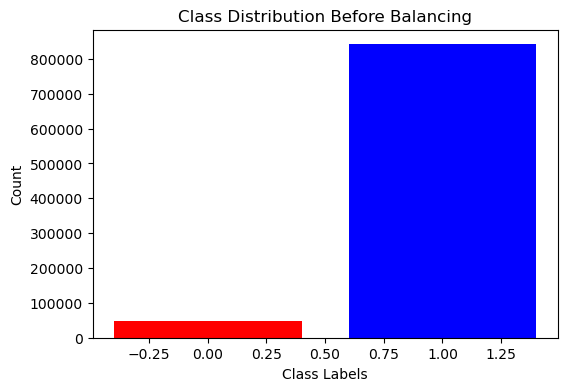

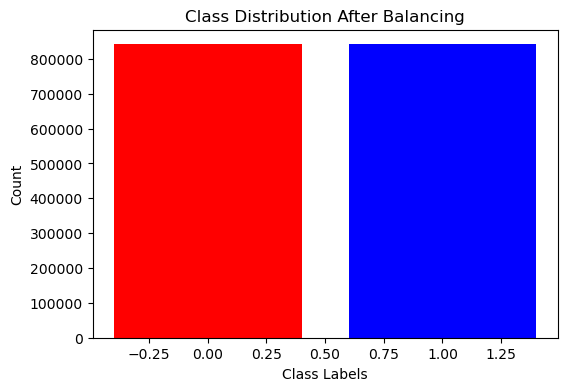

In [19]:
# Get class distribution before balancing
class_counts_before = Counter(df_bin['label'])

# Plot class distribution before balancing
plt.figure(figsize=(6, 4))
plt.bar(class_counts_before.keys(), class_counts_before.values(), color=['blue', 'red'])
plt.xlabel("Class Labels")
plt.ylabel("Count")
plt.title("Class Distribution Before Balancing")
plt.show()

# Get new class distribution after balancing
class_counts_after = Counter(y_resampled)

# Plot class distribution after balancing
plt.figure(figsize=(6, 4))
plt.bar(class_counts_after.keys(), class_counts_after.values(), color=['blue', 'red'])
plt.xlabel("Class Labels")
plt.ylabel("Count")
plt.title("Class Distribution After Balancing")
plt.show()

In [41]:
df_bin['label'].value_counts()


label
1    841694
0    841694
Name: count, dtype: int64

In [39]:
df_balanced = pd.DataFrame(X_resampled, columns=X.columns)
df_balanced['label'] = y_resampled  # Add back the target column
df_bin = df_balanced  # Replace original dataset if needed


In [51]:
X = df_bin.drop(columns=['label'],axis=1)
Y = df_bin['label']

In [53]:
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.3, random_state=50)
     

## Logistic Regression

In [55]:

lr_bin = LogisticRegression()
lr_bin.fit(X_train, y_train)


y_pred = lr_bin.predict(X_test)


cls_report = classification_report(y_test, y_pred, target_names=le_1)
print(cls_report)


print("Accuracy - ", accuracy_score(y_test, y_pred) * 100)


              precision    recall  f1-score   support

    abnormal       0.99      1.00      1.00    252426
      normal       1.00      0.99      1.00    252591

    accuracy                           1.00    505017
   macro avg       1.00      1.00      1.00    505017
weighted avg       1.00      1.00      1.00    505017

Accuracy -  99.74357298863207


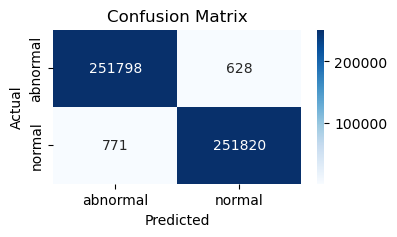

In [77]:
from sklearn.metrics import confusion_matrix
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_1, yticklabels=le_1)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

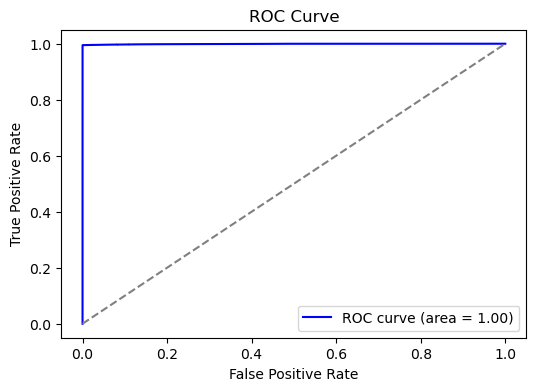

In [103]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

# ROC Curve
y_prob = lr_bin.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [91]:
lr_bin_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

lr_bin_df

,Actual,Predicted
941098,0,0
1562394,0,0
851564,1,1
758056,1,1
1271341,0,0
...,...,...
19616,1,1
884352,1,1
1230617,0,0
1622150,0,0


# Decison Tree

In [89]:
# Train the Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)  # Added random_state for reproducibility
dt_model.fit(X_train, y_train)

# Predictions
dt_y_pred = dt_model.predict(X_test)
dt_y_pred_proba = dt_model.predict_proba(X_test)[:, 1]  # Probabilities for ROC curve (binary)

# Classification Report
dt_cls_report = classification_report(y_test, dt_y_pred, target_names=le_1)
print("Decision Tree Classification Report:\n", dt_cls_report)

# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_y_pred) * 100)

Decision Tree Classification Report:
               precision    recall  f1-score   support

    abnormal       1.00      1.00      1.00    252426
      normal       1.00      1.00      1.00    252591

    accuracy                           1.00    505017
   macro avg       1.00      1.00      1.00    505017
weighted avg       1.00      1.00      1.00    505017

Decision Tree Accuracy: 99.7245637275577


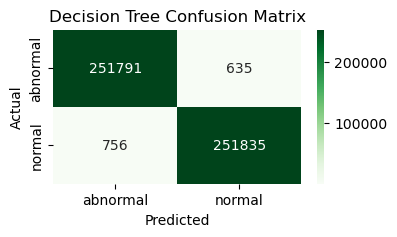

In [97]:
# Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_y_pred)
plt.figure(figsize=(4, 2))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', xticklabels=le_1, yticklabels=le_1)
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

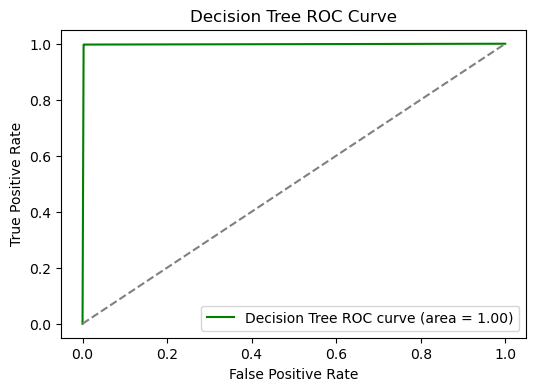

In [105]:
# ROC Curve for Decision Tree
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_y_pred_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(6, 4))
plt.plot(fpr_dt, tpr_dt, color='green', label=f'Decision Tree ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

In [93]:
dt_model_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

dt_model_df

,Actual,Predicted
941098,0,0
1562394,0,0
851564,1,1
758056,1,1
1271341,0,0
...,...,...
19616,1,1
884352,1,1
1230617,0,0
1622150,0,0


## KNN

In [107]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

 
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
 
yk_pred = knn_model.predict(X_test)

 
cls_report = classification_report(y_test, yk_pred, target_names=le_1)
print(cls_report)

# Print accuracy
print("Accuracy - ", accuracy_score(y_test, yk_pred) * 100)


              precision    recall  f1-score   support

    abnormal       1.00      1.00      1.00    252426
      normal       1.00      1.00      1.00    252591

    accuracy                           1.00    505017
   macro avg       1.00      1.00      1.00    505017
weighted avg       1.00      1.00      1.00    505017

Accuracy -  99.7891160099561


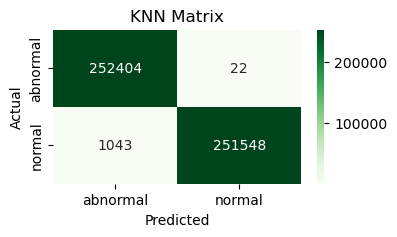

In [109]:
# Confusion Matrix
knn_cm = confusion_matrix(y_test, yk_pred)
plt.figure(figsize=(4, 2))
sns.heatmap(knn_cm, annot=True, fmt='d', cmap='Greens', xticklabels=le_1, yticklabels=le_1)
plt.title('KNN Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

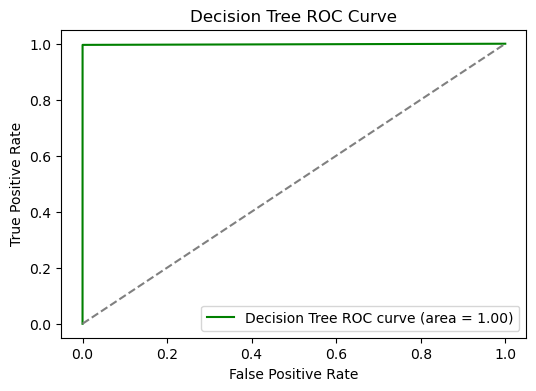

In [113]:
# ROC Curve 
fpr_knn, tpr_knn, _ = roc_curve(y_test, yk_pred)
roc_auc_knn = auc(fpr_knn, tpr_knn)

plt.figure(figsize=(6, 4))
plt.plot(fpr_knn, tpr_knn, color='green', label=f'Decision Tree ROC curve (area = {roc_auc_knn:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

In [115]:
knn_bin_df = pd.DataFrame({'Actual': y_test, 'Predicted': yk_pred})

knn_bin_df

,Actual,Predicted
941098,0,0
1562394,0,0
851564,1,1
758056,1,1
1271341,0,0
...,...,...
19616,1,1
884352,1,1
1230617,0,0
1622150,0,0


## Random Forest

In [117]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
 
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

 
yr_pred = rf_model.predict(X_test)

 
cls_report = classification_report(y_test, yr_pred, target_names=le_1)
print(cls_report)

 
print("Accuracy - ", accuracy_score(y_test, yr_pred) * 100)


              precision    recall  f1-score   support

    abnormal       1.00      1.00      1.00    252426
      normal       1.00      1.00      1.00    252591

    accuracy                           1.00    505017
   macro avg       1.00      1.00      1.00    505017
weighted avg       1.00      1.00      1.00    505017

Accuracy -  99.81426367825242


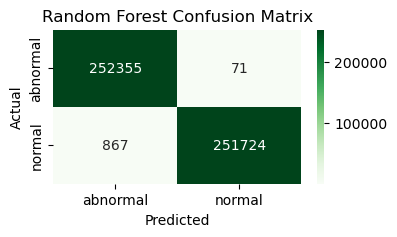

In [121]:
# Confusion Matrix
r_cm = confusion_matrix(y_test, yr_pred)
plt.figure(figsize=(4, 2))
sns.heatmap(r_cm, annot=True, fmt='d', cmap='Greens', xticklabels=le_1, yticklabels=le_1)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

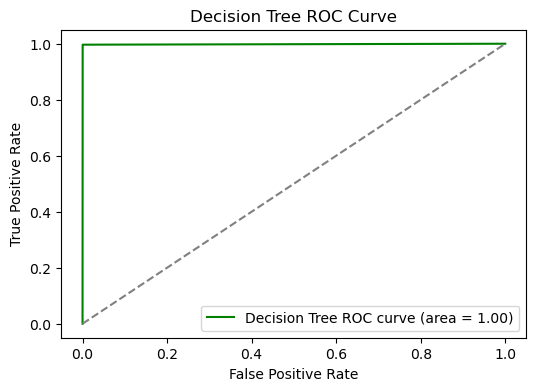

In [123]:
# ROC Curve  
fpr_r, tpr_r, _ = roc_curve(y_test, yr_pred)
roc_auc_r = auc(fpr_r, tpr_r)

plt.figure(figsize=(6, 4))
plt.plot(fpr_r, tpr_r, color='green', label=f'Decision Tree ROC curve (area = {roc_auc_r:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")
plt.legend()
plt.show()

In [125]:
rf_bin_df = pd.DataFrame({'Actual': y_test, 'Predicted': yk_pred})

rf_bin_df

,Actual,Predicted
941098,0,0
1562394,0,0
851564,1,1
758056,1,1
1271341,0,0
...,...,...
19616,1,1
884352,1,1
1230617,0,0
1622150,0,0


In [127]:
import joblib

 
joblib.dump(lr_bin, "logistic_model_bin.pkl")

['logistic_model_bin.pkl']

In [129]:
joblib.dump(dt_model, "Descion_tree_model_bin.pkl")

['Descion_tree_model_bin.pkl']

In [131]:
joblib.dump(knn_model, "KNN_model_bin.pkl")

['KNN_model_bin.pkl']

In [133]:
joblib.dump(rf_model, "Random_Forest_model_bin.pkl")

['Random_Forest_model_bin.pkl']